Extra Trees:
  MAE: 100705.93, RMSE: 196160.23, R²: 0.99
  Accuracy @10%: 0.80, @20%: 1.00, @30%: 1.00

XGBoost:
  MAE: 90349.55, RMSE: 157182.64, R²: 0.99
  Accuracy @10%: 0.80, @20%: 0.90, @30%: 1.00

Stacked Model:
  MAE: 92823.63, RMSE: 130817.86, R²: 0.99
  Accuracy @10%: 0.90, @20%: 1.00, @30%: 1.00



<ipython-input-2-1fcaffd981fa>:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')
<ipython-input-2-1fcaffd981fa>:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')
<ipython-input-2-1fcaffd981fa>:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')
<ipython-input-2-1fcaffd981fa>:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

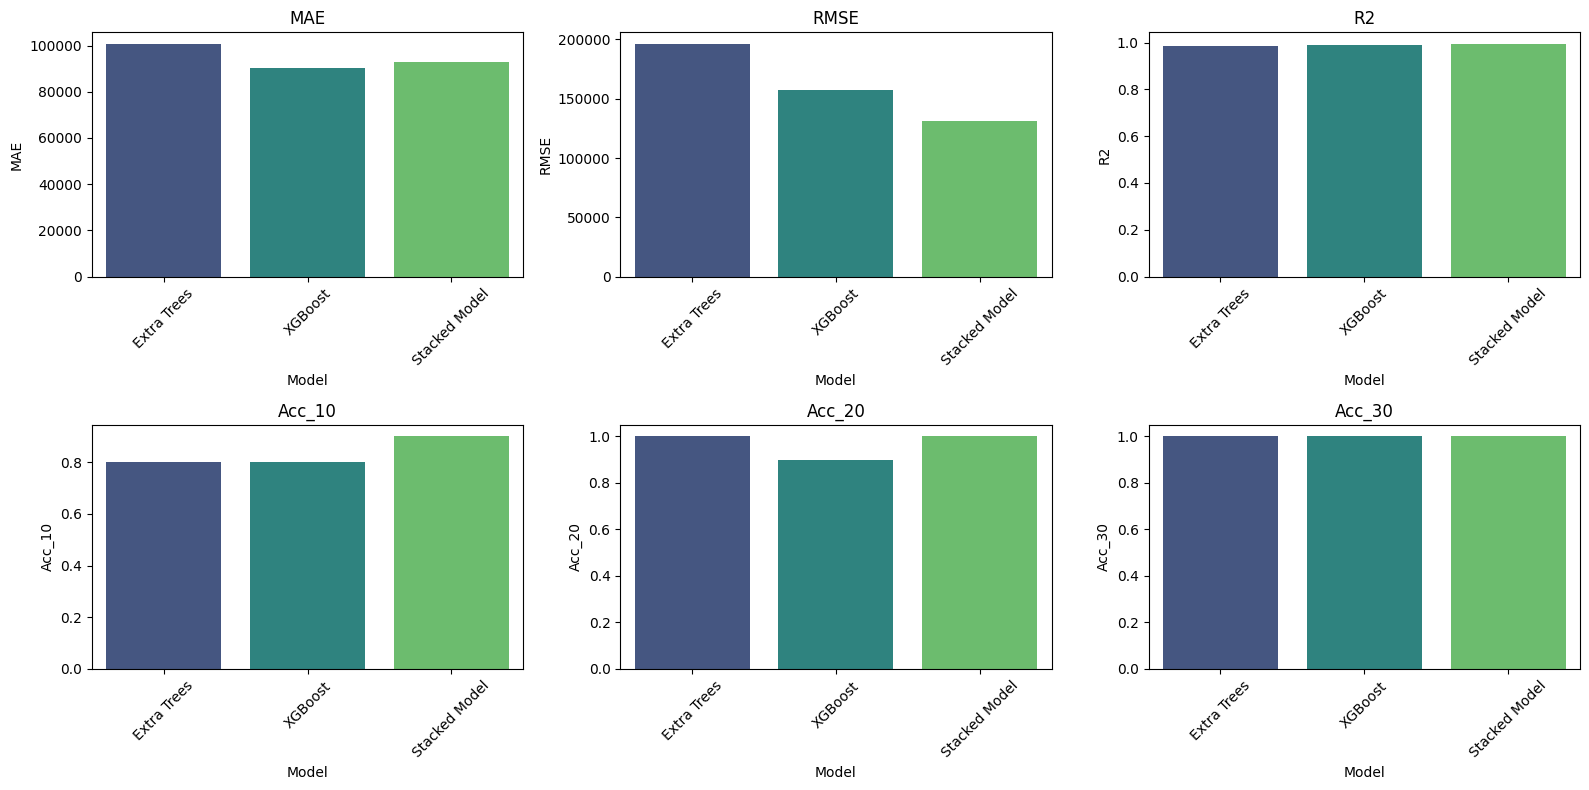

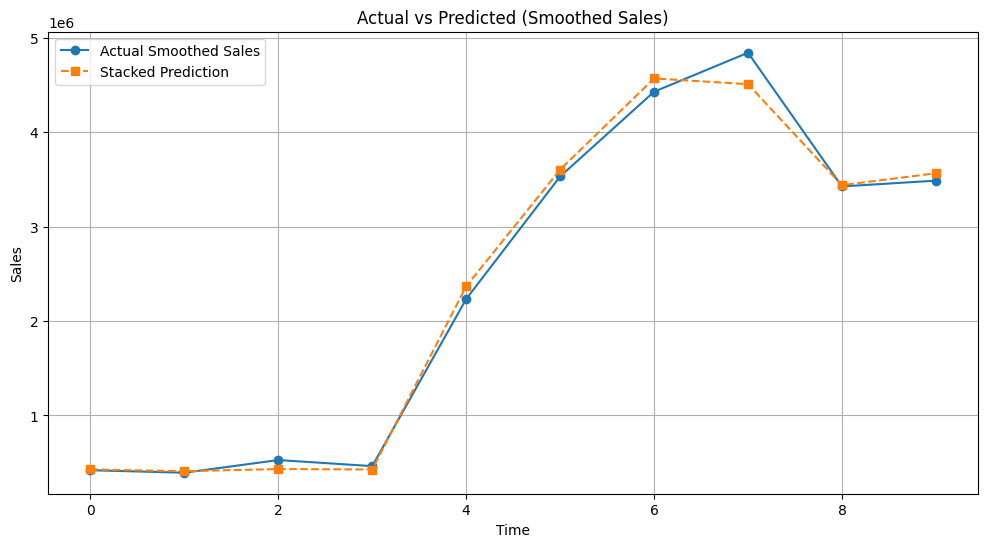

In [2]:
# AMAZON SALES FORECASTING - FOCUSED ON ACCURACY@30%

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =================== #
# LOAD & PROCESS DATA
# =================== #
df = pd.read_csv('Amazon Sales Records (2) (1).csv')
df.rename(columns={'Total Revenue': 'Sales'}, inplace=True)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df_grouped = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
df_grouped['Date'] = pd.to_datetime(df_grouped[['Year', 'Month']].assign(DAY=1))
df_grouped = df_grouped.sort_values('Date')

# =================== #
# FEATURE ENGINEERING
# =================== #
df_grouped['Lag_1'] = df_grouped['Sales'].shift(1)
df_grouped['Lag_2'] = df_grouped['Sales'].shift(2)
df_grouped['Lag_3'] = df_grouped['Sales'].shift(3)
df_grouped['Lag_4'] = df_grouped['Sales'].shift(4)
df_grouped['Lag_6'] = df_grouped['Sales'].shift(6)
df_grouped['Lag_12'] = df_grouped['Sales'].shift(12)

df_grouped['Moving_Avg_3'] = df_grouped['Sales'].rolling(window=3).mean()
df_grouped['Rolling_Std_3'] = df_grouped['Sales'].rolling(window=3).std()
df_grouped['Sales_Trend'] = df_grouped['Lag_1'] - df_grouped['Lag_2']

df_grouped['Month_sin'] = np.sin(2 * np.pi * df_grouped['Month'] / 12)
df_grouped['Month_cos'] = np.cos(2 * np.pi * df_grouped['Month'] / 12)

# Smooth the sales for prediction target
df_grouped['Sales_Smoothed'] = df_grouped['Sales'].rolling(window=3).mean()
df_grouped.dropna(inplace=True)

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_6', 'Lag_12',
            'Moving_Avg_3', 'Rolling_Std_3', 'Sales_Trend',
            'Month_sin', 'Month_cos']

X = df_grouped[features]
y = df_grouped['Sales_Smoothed']

# =================== #
# TRAIN-TEST SPLIT
# =================== #
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# =================== #
# MODEL TRAINING
# =================== #
et_model = ExtraTreesRegressor(n_estimators=300, max_depth=10, random_state=42)
et_model.fit(X_train, y_train)
et_preds = et_model.predict(X_test)

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# =================== #
# STACKED MODEL
# =================== #
stacked_features = np.column_stack((et_preds, xgb_preds))
meta_model = LinearRegression()
meta_model.fit(stacked_features, y_test)
stacked_preds = meta_model.predict(stacked_features)

# =================== #
# EVALUATION FUNCTIONS
# =================== #
def regression_accuracy(y_true, y_pred, tolerance=0.3):
    return np.mean(np.abs(y_true - y_pred) <= (tolerance * np.abs(y_true)))

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    acc_10 = regression_accuracy(y_true, y_pred, 0.1)
    acc_20 = regression_accuracy(y_true, y_pred, 0.2)
    acc_30 = regression_accuracy(y_true, y_pred, 0.3)

    print(f"{model_name}:\n  MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
    print(f"  Accuracy @10%: {acc_10:.2f}, @20%: {acc_20:.2f}, @30%: {acc_30:.2f}\n")

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2,
            'Acc_10': acc_10, 'Acc_20': acc_20, 'Acc_30': acc_30}

# =================== #
# EVALUATE MODELS
# =================== #
results = []
results.append(evaluate_model(y_test, et_preds, "Extra Trees"))
results.append(evaluate_model(y_test, xgb_preds, "XGBoost"))
results.append(evaluate_model(y_test, stacked_preds, "Stacked Model"))

# =================== #
# VISUALIZATION
# =================== #
results_df = pd.DataFrame(results)
metrics = ['MAE', 'RMSE', 'R2', 'Acc_10', 'Acc_20', 'Acc_30']

plt.figure(figsize=(16, 8))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x='Model', y=metric, data=results_df, palette='viridis')
    plt.title(metric)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =================== #
# PREDICTION PLOT
# =================== #
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Smoothed Sales", marker='o')
plt.plot(stacked_preds, label="Stacked Prediction", linestyle='dashed', marker='s')
plt.title("Actual vs Predicted (Smoothed Sales)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


In [4]:
import joblib
joblib.dump(meta_model, 'stacked_sales_model.pkl')

['stacked_sales_model.pkl']